In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

/home/huzaifa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv("datasets/insurance.csv")

In [3]:
# Shape of the dataset

print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 1338
Columns: 7


In [4]:
# First 5 rows of the dataset

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Make a numerical copy of the dataset

df_numerical = df.select_dtypes(include="number").copy()

In [6]:
# Null Value Check

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# How many duplicated rows

df.duplicated().sum()

1

In [8]:
# Check skew 

df_numerical.skew()

age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

## Section I: Preprocessing

In [9]:
# Remove duplicate rows

df = df[df.duplicated() == False]

## Section II: EDA

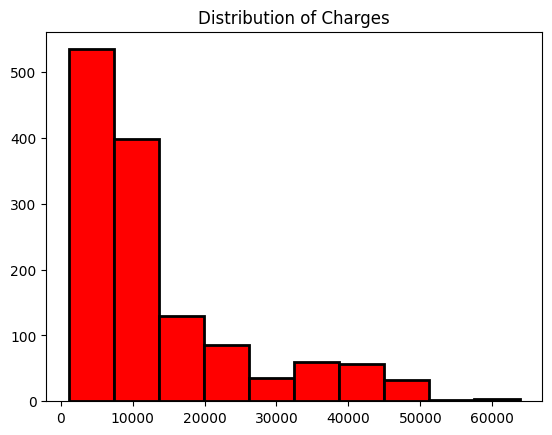

In [10]:
# Check the distribution of charges

plt.hist(df['charges'], linewidth=2, edgecolor='black', color="red")
plt.title("Distribution of Charges")
plt.show()

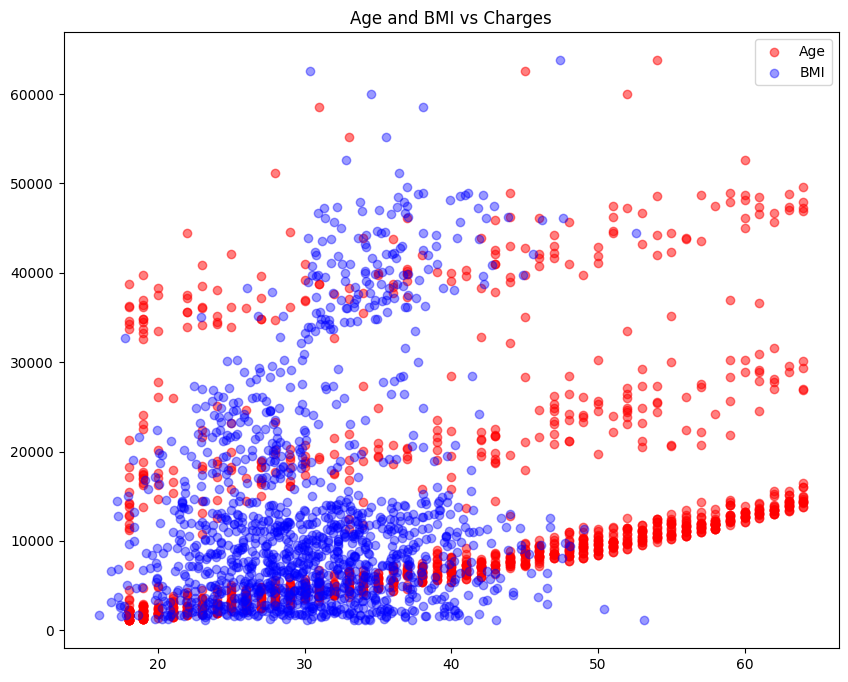

In [11]:
# Plot Age and BMI vs Charges

plt.figure(figsize=(10, 8))
plt.scatter(x=df['age'].values, y=df['charges'].values, color='red', alpha=0.5, label='Age')
plt.scatter(x=df['bmi'].values, y=df['charges'].values, color='blue', alpha=0.4, label='BMI')
plt.title("Age and BMI vs Charges")
plt.legend()
plt.show()

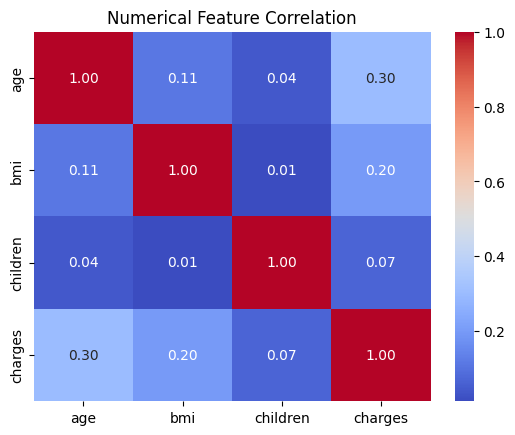

In [12]:
# See the most correlated numerical features
_corr = df_numerical.corr()

sns.heatmap(data=_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Numerical Feature Correlation")
plt.show()

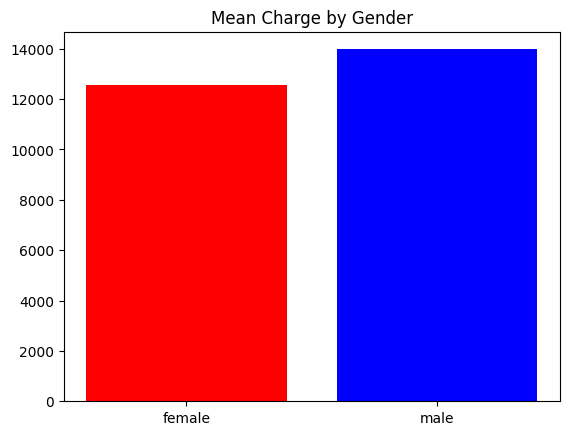

In [13]:
# Effect of gender on charges - The mean charge per gender

mean_charge_by_gender = df.groupby('sex')['charges'].mean()

plt.bar(mean_charge_by_gender.index, mean_charge_by_gender.values, color=['red', 'blue'])
plt.title("Mean Charge by Gender")
plt.show()

## Section III: Model Application

In [14]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [15]:
# Encode the dataset

le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

one_hot_cols = ['sex', 'region']

charges_col = df['charges']
df.drop('charges', axis=1, inplace=True)

for col in one_hot_cols:
    obj = ohe.fit_transform(df[[col]])
    df.drop(col, axis=1, inplace=True)
    df = pd.concat([df, obj], axis=1)

df['smoker'] = le.fit_transform(df['smoker'])

df = pd.concat([df, charges_col], axis=1)

df.head()



,age,bmi,children,smoker,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,charges
0,19,27.900,0,1,1.0,0.0,0.0,0.0,0.0,1.0,16884.92400
1,18,33.770,1,0,0.0,1.0,0.0,0.0,1.0,0.0,1725.55230
2,28,33.000,3,0,0.0,1.0,0.0,0.0,1.0,0.0,4449.46200
3,33,22.705,0,0,0.0,1.0,0.0,1.0,0.0,0.0,21984.47061
4,32,28.880,0,0,0.0,1.0,0.0,1.0,0.0,0.0,3866.85520


In [16]:
# Extract X and y

X = df.iloc[:, :-1].values
y = df['charges'].values

In [17]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Run a simple decision tree regressor

dtr = DecisionTreeRegressor(max_depth=3)

dtr.fit(X_train, y_train)
y_pred_dtr = dtr.predict(X_test)

In [19]:
# Cross validate

kf = KFold(n_splits=10)
preboost_cvscore_mean = -cross_val_score(dtr, X, y, cv=kf, scoring='neg_root_mean_squared_error').mean()
print(f"Mean cross val score: {preboost_cvscore_mean}")

Mean cross val score: 4730.806418584622


## Section IV: Boosting Models

In [20]:
# Custom gradient boosting function
import time

start = time.perf_counter()

M = 1000
learning_rate = 0.01

def gradient_boost(X, y, M, learning_rate):
    F = None
    r = None
    models = []
    for m in range(M+1):
        if m == 0:
            F = np.array([np.mean(y) for _ in range(y.shape[0])])
            r = y - F
        else:
            model = DecisionTreeRegressor(max_depth=3)
            model.fit(X, r)
            y_pred = model.predict(X)

            F = F + learning_rate * y_pred
            r = y - F
            models.append(model)
    return models

models = gradient_boost(X_train, y_train, M, learning_rate)

end = time.perf_counter()

print(f"Computation time: {end - start:.4f} seconds")

Computation time: 1.3998 seconds


In [21]:
# Find the final y_pred values

y_pred_post_boost = np.array([np.mean(y_train) for _ in range(y_test.shape[0])])

for model in models:
    y_pred_post_boost += learning_rate * model.predict(X_test)

post_boost_rmse = math.sqrt(mean_squared_error(y_test, y_pred_post_boost))
print(f"RMSE: {post_boost_rmse}")

RMSE: 4246.828582978164


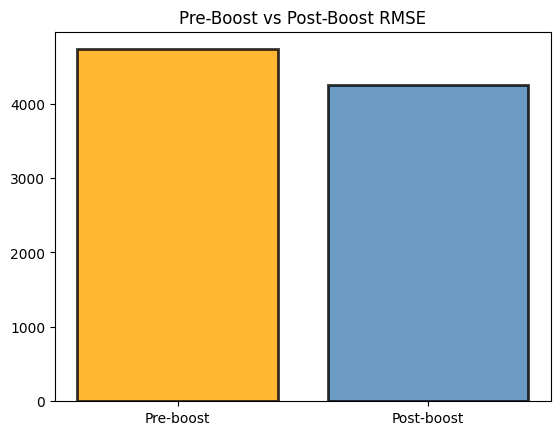

In [22]:
# Plotting RMSE

labels=['Pre-boost', 'Post-boost']
values=[preboost_cvscore_mean, post_boost_rmse]

plt.bar(labels, values, color=['orange', 'steelblue'], edgecolor='black', linewidth=2, alpha=0.8)
plt.title("Pre-Boost vs Post-Boost RMSE")
plt.show()